In [40]:
import sys
import os
import matplotlib.pyplot as plt
# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from crater_analysis.io import read_crater_locations, read_dem
from crater_analysis.analysis import filter_craters, get_crater_profile, get_dem_snippet
from crater_analysis.plotting import plot_dem, plot_crater_locations
from crater_analysis.core import Crater

In [42]:
dem, metadata = read_dem('../data/dems/LDEM_60N_120M.JP2')

Successfully read DEM from ../data/dems/LDEM_60N_120M.JP2


In [43]:
#lat = 'LAT_CIRC_IMG'
#lon = 'LON_CIRC_IMG'
#diam = 'DIAM_CIRC_IMG'
lat = 'lat'
lon = 'lon'
diam = 'diameter_m'
depth = 'depth_m'

#craters = read_crater_locations('../data/catalogs/lunar_crater_database_robbins_2018.csv')
#craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=None, diam_min=8, diam_max=None, lat_col=lat, diam_col=diam)

craters = read_crater_locations('../data/catalogs/moon_data.csv')
craters = filter_craters(craters, pole='north', lat_threshold=60, circ_threshold=0.85, diam_min=2500, diam_max=None, lat_col=lat, diam_col=diam)

craters.head()

Successfully read 11228 crater locations from ../data/catalogs/moon_data.csv
Filtered to 3227 craters matching criteria.


,lat,lon,depth_m,diameter_m,dD,pf_slope,ef_slope,circ,test
6363,60.005,18.963,1377.60,7994.8,0.17231,0.37225,0.45062,0.99999,0
6365,60.029,129.070,542.94,4381.6,0.12391,0.24534,0.29121,0.94021,0
6367,60.040,-95.130,1273.70,8578.1,0.14848,0.11129,0.36718,0.89442,0
6368,60.040,111.150,639.39,4620.5,0.13838,0.23518,0.23841,0.96351,0
6371,60.053,-108.430,456.23,4113.4,0.11091,0.20499,0.27677,0.87647,0


In [44]:
### Initialise Craters ###
# Create an empty list to hold the Crater objects
crater_objects = []

# Loop through the first few rows of the DataFrame for demonstration
# To process all craters, change `craters.head(1).iterrows()` to `craters.iterrows()`
for index, row in craters.iterrows():
    # Extract crater properties from the row
    crater_id = None #row['CRATER_ID']
    crater_lon = row[lon]
    crater_lat = row[lat]
    crater_diam_km = row[diam] /1000.0  # Convert diameter from meters to kilometers
    crater_depth_m = row[depth]
    
    # Get the DEM snippet for this crater
    dem_snippet, snippet_meta, center_coords = get_dem_snippet(
        dem,
        metadata,
        crater_lon,
        crater_lat,
        crater_diam_km,
        padding_factor=1.5
    )
    
    # Create the Crater object
    crater_obj = Crater(
        crater_id=crater_id,
        dem_snippet=dem_snippet,
        metadata=snippet_meta,
        center_coords=center_coords,
        global_coords={'lon': crater_lon, 'lat': crater_lat},
    )
    
    crater_obj.add_property('diameter_km', crater_diam_km)
    crater_obj.add_property('depth_m', crater_depth_m)

    # Add the new object to our list
    crater_objects.append(crater_obj)

    if index % 100 == 0:
        print(f'Processed crater {index}')

# Print a summary to confirm it worked
print(f"Successfully initialized {len(crater_objects)} Crater objects.")
if crater_objects:
    print("First crater object in the list:")
    print(crater_objects[50])
    print(crater_objects[50].dem_data)
print(dem)

Processed crater 6400
Processed crater 6500
Processed crater 6500
Processed crater 6800
Processed crater 6800
Processed crater 7000
Processed crater 7000
Processed crater 7100
Processed crater 7100
Processed crater 7300
Processed crater 7300
Processed crater 7400
Processed crater 7400
Processed crater 7500
Processed crater 7500
Processed crater 7600
Processed crater 7600
Processed crater 7700
Processed crater 7700
Processed crater 7800
Processed crater 7800
Processed crater 7900
Processed crater 7900
Processed crater 8000
Processed crater 8000
Processed crater 8100
Processed crater 8100
Processed crater 8200
Processed crater 8200
Processed crater 8300
Processed crater 8300
Processed crater 8400
Processed crater 8400
Processed crater 8500
Processed crater 8500
Processed crater 8600
Processed crater 8600
Processed crater 8800
Processed crater 8800
Processed crater 8900
Processed crater 8900
Processed crater 9100
Processed crater 9100
Processed crater 9200
Processed crater 9200
Processed 

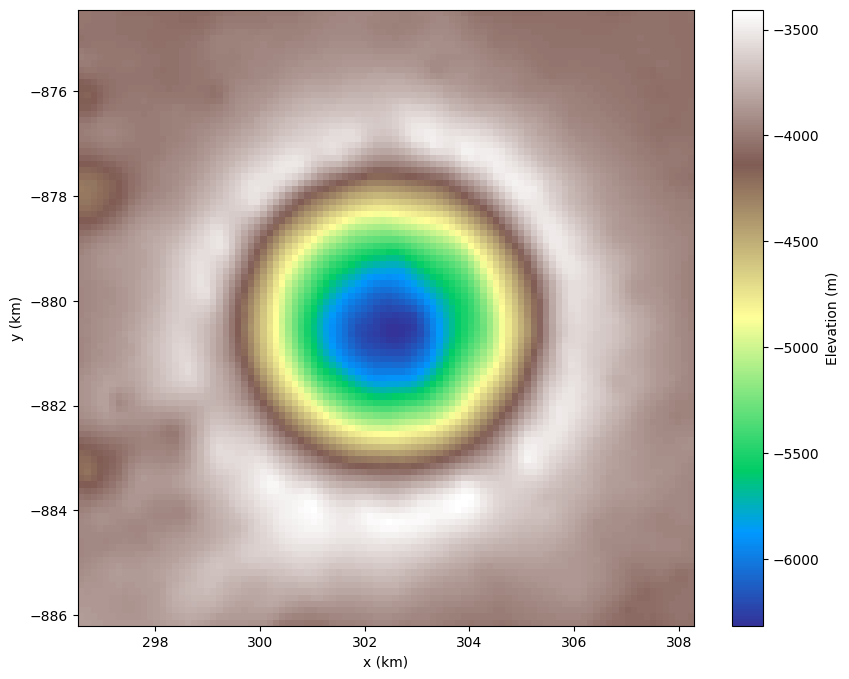

(<Figure size 1000x800 with 2 Axes>, <Axes: xlabel='x (km)', ylabel='y (km)'>)

In [45]:
plot_dem(crater_objects[0].dem_data, crater_objects[0].metadata)

## Extract a 2D Profile from a Crater

The `get_crater_profile` function uses Bresenham's line algorithm to sample actual pixel values along the profile, giving you the true DEM resolution without any interpolation.

Parameters:
- `dem_data`: The DEM array (can be the full DEM or a snippet)
- `metadata`: The corresponding metadata
- `crater_lon`, `crater_lat`: The crater's center coordinates
- `crater_diam_km`: The crater's diameter in kilometers
- `angle`: Angle of the profile in degrees (0=horizontal/E-W, 90=vertical/N-S)

DEM Snippet Stats:
  Min: -6316
  Max: -3406
  Mean: -4058.605997501041
  Nodata value: None

Profile Stats:
  Horizontal Profile - Min: -6314, Max: -3581, Range: 2733
  Vertical Profile   - Min: -6310, Max: -3428, Range: 2882

Horizontal profile: 98 pixels, slope=11.04 m/km
Vertical profile: 98 pixels, slope=86.85 m/km

Profile Stats:
  Horizontal Profile - Min: -6314, Max: -3581, Range: 2733
  Vertical Profile   - Min: -6310, Max: -3428, Range: 2882

Horizontal profile: 98 pixels, slope=11.04 m/km
Vertical profile: 98 pixels, slope=86.85 m/km


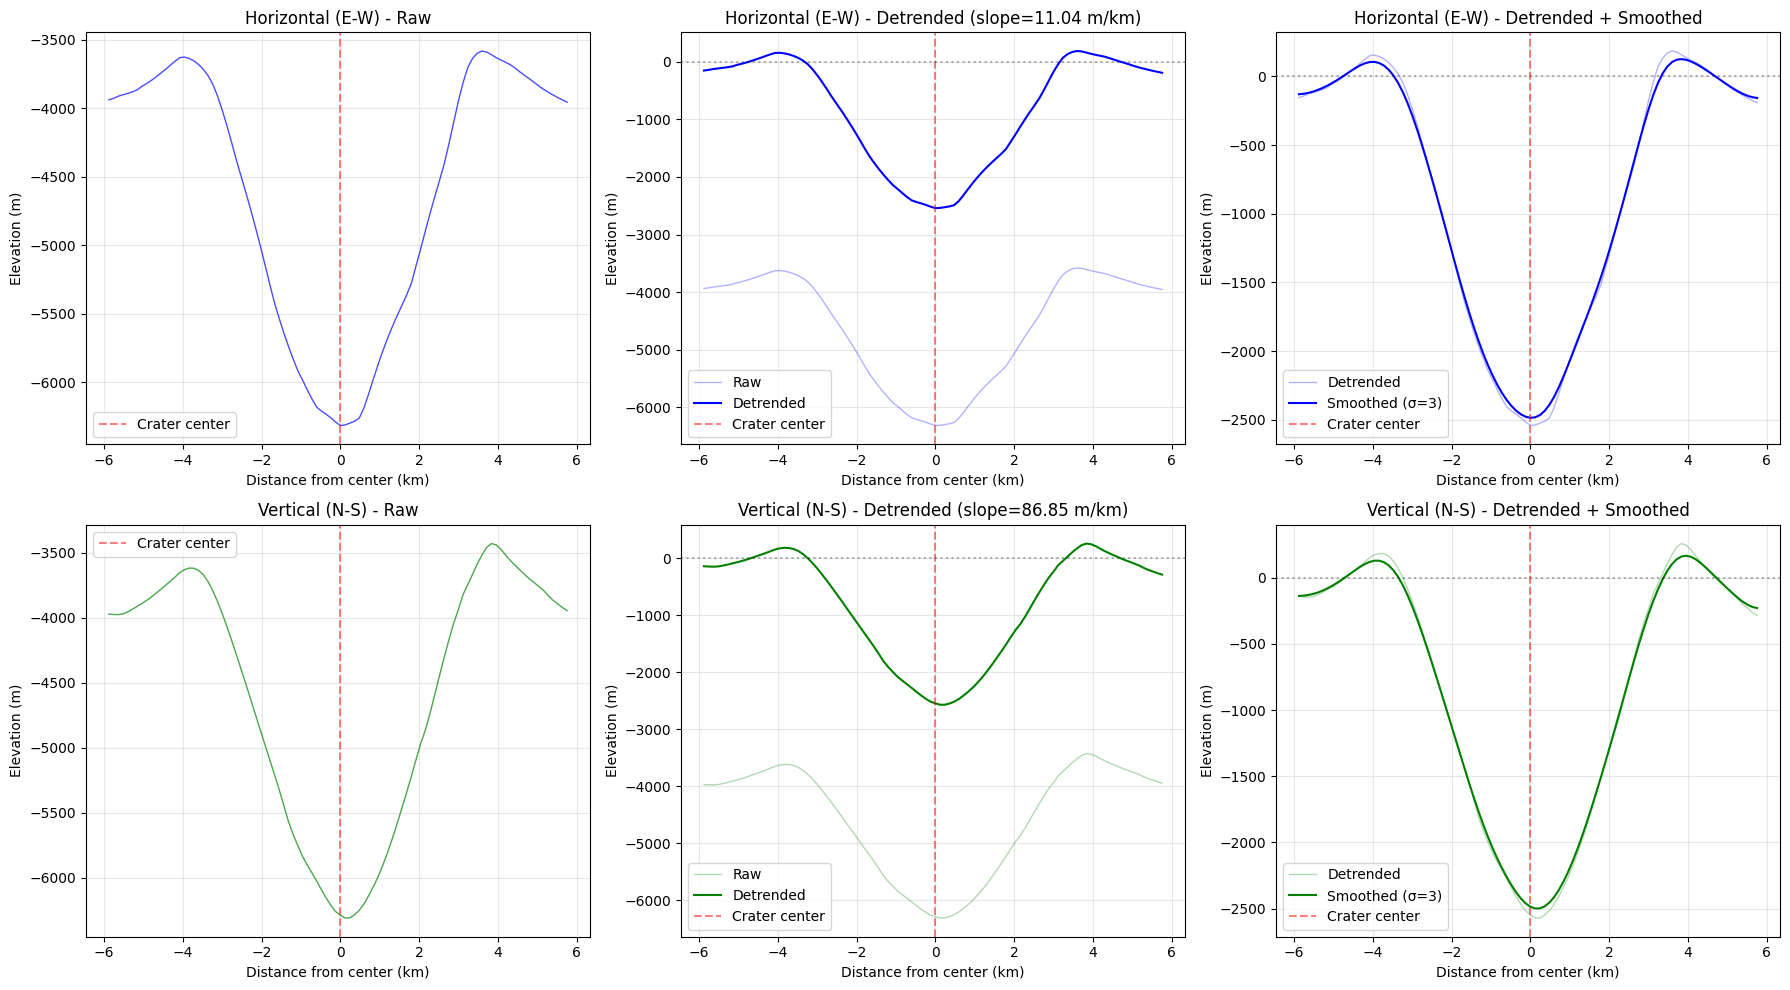

In [46]:
# Import the analysis functions
from crater_analysis.analysis import detrend_profile, smooth_profile, detrend_profile_robust
import numpy as np

# Extract profiles in both horizontal and vertical directions
crater = crater_objects[0]

# Check DEM stats
print(f"DEM Snippet Stats:")
print(f"  Min: {np.min(crater.dem_data)}")
print(f"  Max: {np.max(crater.dem_data)}")
print(f"  Mean: {np.mean(crater.dem_data)}")
print(f"  Nodata value: {crater.metadata.get('nodata')}")

# Horizontal profile (E-W, angle=0)
distance_h, elevation_h, pixel_coords_h = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.5,
    angle=0  # 0 degrees = horizontal (E-W)
)

# Vertical profile (N-S, angle=90)
distance_v, elevation_v, pixel_coords_v = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.5,
    angle=90  # 90 degrees = vertical (N-S)
)

print(f"\nProfile Stats:")
print(f"  Horizontal Profile - Min: {np.min(elevation_h)}, Max: {np.max(elevation_h)}, Range: {np.ptp(elevation_h)}")
print(f"  Vertical Profile   - Min: {np.min(elevation_v)}, Max: {np.max(elevation_v)}, Range: {np.ptp(elevation_v)}")

# Detrend the profiles first to remove regional slope
# Using robust detrending to avoid fitting the crater shape itself
elevation_h_detrended, slope_h, intercept_h = detrend_profile_robust(distance_h, elevation_h, fraction=0.2)
elevation_v_detrended, slope_v, intercept_v = detrend_profile_robust(distance_v, elevation_v, fraction=0.2)

# Then apply Gaussian smoothing to remove small-scale noise
# sigma controls the amount of smoothing (larger = more smoothing)
sigma = 3  # Try values between 1-5 depending on noise level
elevation_h_smooth = smooth_profile(elevation_h_detrended, sigma=sigma)
elevation_v_smooth = smooth_profile(elevation_v_detrended, sigma=sigma)

print(f"\nHorizontal profile: {len(elevation_h)} pixels, slope={slope_h:.2f} m/km")
print(f"Vertical profile: {len(elevation_v)} pixels, slope={slope_v:.2f} m/km")

# Plot raw, detrended, and smoothed profiles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Horizontal profile - Raw
axes[0, 0].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title(f'Horizontal (E-W) - Raw')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal profile - Detrended
axes[0, 1].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.3, label='Raw')
axes[0, 1].plot(distance_h, elevation_h_detrended, '-', linewidth=1.5, color='blue', label=f'Detrended')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Elevation (m)')
axes[0, 1].set_title(f'Horizontal (E-W) - Detrended (slope={slope_h:.2f} m/km)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Horizontal profile - Smoothed
axes[0, 2].plot(distance_h, elevation_h_detrended, '-', linewidth=1, color='blue', alpha=0.3, label='Detrended')
axes[0, 2].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label=f'Smoothed (σ={sigma})')
axes[0, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 2].set_xlabel('Distance from center (km)')
axes[0, 2].set_ylabel('Elevation (m)')
axes[0, 2].set_title(f'Horizontal (E-W) - Detrended + Smoothed')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Vertical profile - Raw
axes[1, 0].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title(f'Vertical (N-S) - Raw')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical profile - Detrended
axes[1, 1].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.3, label='Raw')
axes[1, 1].plot(distance_v, elevation_v_detrended, '-', linewidth=1.5, color='green', label=f'Detrended')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Elevation (m)')
axes[1, 1].set_title(f'Vertical (N-S) - Detrended (slope={slope_v:.2f} m/km)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Vertical profile - Smoothed
axes[1, 2].plot(distance_v, elevation_v_detrended, '-', linewidth=1, color='green', alpha=0.3, label='Detrended')
axes[1, 2].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='green', label=f'Smoothed (σ={sigma})')
axes[1, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 2].set_xlabel('Distance from center (km)')
axes[1, 2].set_ylabel('Elevation (m)')
axes[1, 2].set_title(f'Vertical (N-S) - Detrended + Smoothed')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal profile floor: distance=0.360 km, elevation=-2436.82 m
Vertical profile floor: distance=0.240 km, elevation=-2497.67 m


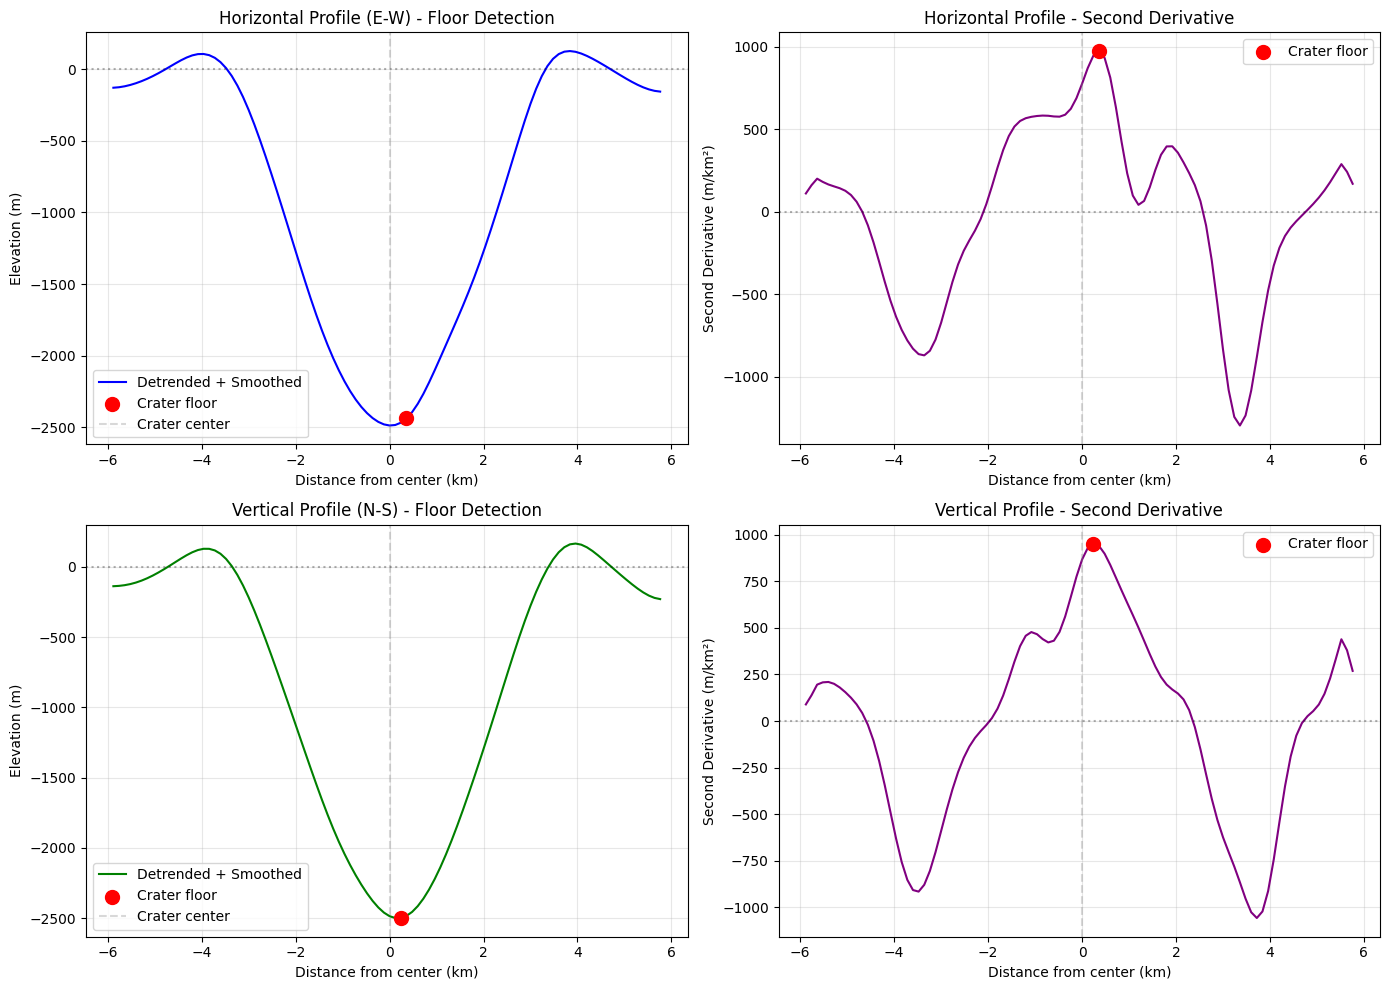

In [47]:
# Import the crater floor finding function
from crater_analysis.analysis import find_crater_floor, find_crater_floor_max_curv

# Find the deepest point in the horizontal profile (using smoothed data)
floor_idx_h, floor_dist_h, floor_elev_h, second_deriv_h = find_crater_floor_max_curv(distance_h, elevation_h_smooth)

# Find the deepest point in the vertical profile (using smoothed data)
floor_idx_v, floor_dist_v, floor_elev_v, second_deriv_v = find_crater_floor_max_curv(distance_v, elevation_v_smooth)

print(f"Horizontal profile floor: distance={floor_dist_h:.3f} km, elevation={floor_elev_h:.2f} m")
print(f"Vertical profile floor: distance={floor_dist_v:.3f} km, elevation={floor_elev_v:.2f} m")

# Plot the profiles with the identified floor locations and second derivatives
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Horizontal profile with floor marked
axes[0, 0].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Crater floor')
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title('Horizontal Profile (E-W) - Floor Detection')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal second derivative
axes[0, 1].plot(distance_h, second_deriv_h, '-', linewidth=1.5, color='purple')
axes[0, 1].scatter(floor_dist_h, second_deriv_h[floor_idx_h], color='red', s=100, zorder=5, label='Crater floor')
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Second Derivative (m/km²)')
axes[0, 1].set_title('Horizontal Profile - Second Derivative')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Vertical profile with floor marked
axes[1, 0].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='green', label='Detrended + Smoothed')
axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Crater floor')
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title('Vertical Profile (N-S) - Floor Detection')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical second derivative
axes[1, 1].plot(distance_v, second_deriv_v, '-', linewidth=1.5, color='purple')
axes[1, 1].scatter(floor_dist_v, second_deriv_v[floor_idx_v], color='red', s=100, zorder=5, label='Crater floor')
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Second Derivative (m/km²)')
axes[1, 1].set_title('Vertical Profile - Second Derivative')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal profile:
  Left rim: -3.960 km, Right rim: 3.720 km
  Measured diameter: 7.680 km
  Depth: 2591.56 m (Center elev: -2478.45 m, Avg rim elev: 113.12 m)

Vertical profile:
  Left rim: -3.840 km, Right rim: 3.960 km
  Measured diameter: 7.800 km
  Depth: 2631.54 m (Center elev: -2485.48 m, Avg rim elev: 146.05 m)

Catalog diameter: 7.995 km
Measured diameter: 7.740 km

Catalog depth: 1377.60 m
Average Measured Depth: 2611.55 m
Difference (Measured - Catalog): 1233.95 m


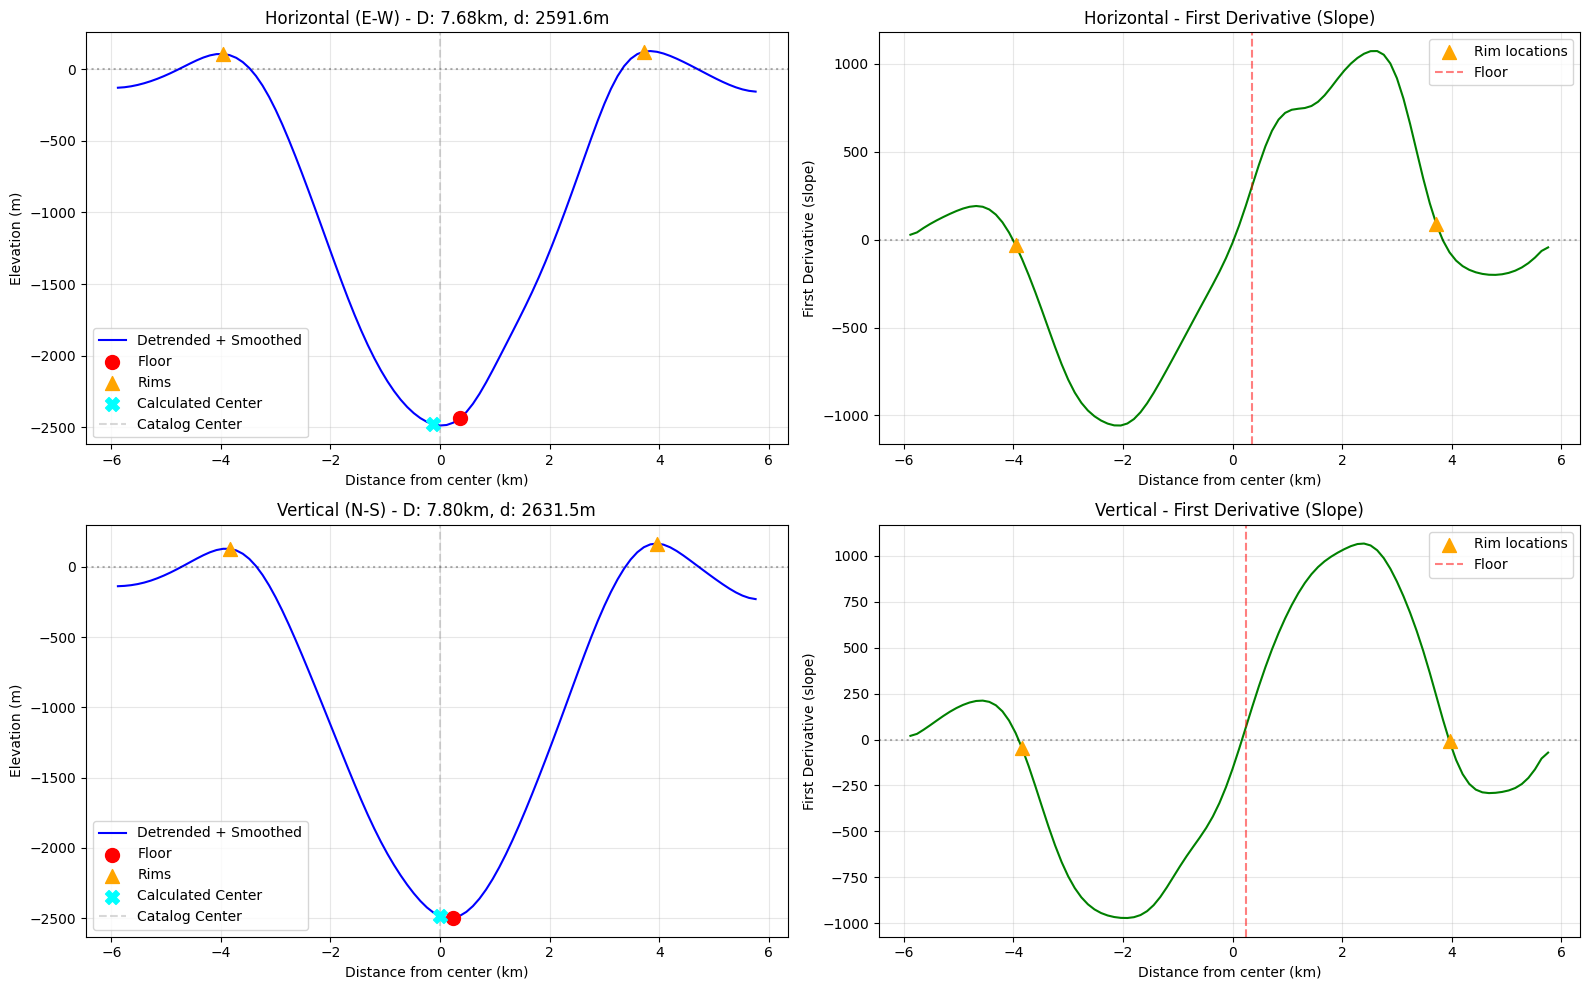

In [48]:
# Import the crater rim finding function
from crater_analysis.analysis import find_crater_rims

try:
    # Find the rims for both profiles (using smoothed data)
    left_rim_idx_h, right_rim_idx_h, left_rim_dist_h, right_rim_dist_h, first_deriv_h = find_crater_rims(
        distance_h, elevation_h_smooth, floor_idx_h, threshold_fraction=0.1
    )

    left_rim_idx_v, right_rim_idx_v, left_rim_dist_v, right_rim_dist_v, first_deriv_v = find_crater_rims(
        distance_v, elevation_v_smooth, floor_idx_v, threshold_fraction=0.1
    )

    # Calculate diameters
    diameter_h = right_rim_dist_h - left_rim_dist_h
    diameter_v = right_rim_dist_v - left_rim_dist_v

    # Calculate depth for Horizontal Profile
    # Center is the midpoint index between the two rims
    center_idx_h = (left_rim_idx_h + right_rim_idx_h) // 2
    center_dist_h = distance_h[center_idx_h]
    center_elev_h = elevation_h_smooth[center_idx_h]
    
    # Average rim elevation
    avg_rim_elev_h = (elevation_h_smooth[left_rim_idx_h] + elevation_h_smooth[right_rim_idx_h]) / 2
    
    # Depth is difference between average rim elevation and center elevation
    depth_h = avg_rim_elev_h - center_elev_h

    # Calculate depth for Vertical Profile
    center_idx_v = (left_rim_idx_v + right_rim_idx_v) // 2
    center_dist_v = distance_v[center_idx_v]
    center_elev_v = elevation_v_smooth[center_idx_v]
    
    avg_rim_elev_v = (elevation_v_smooth[left_rim_idx_v] + elevation_v_smooth[right_rim_idx_v]) / 2
    depth_v = avg_rim_elev_v - center_elev_v

    # Average Depth across both profiles
    avg_depth = (depth_h + depth_v) / 2
    
    # Get catalog depth
    catalog_depth = crater.get_property('depth_m')

    print(f"Horizontal profile:")
    print(f"  Left rim: {left_rim_dist_h:.3f} km, Right rim: {right_rim_dist_h:.3f} km")
    print(f"  Measured diameter: {diameter_h:.3f} km")
    print(f"  Depth: {depth_h:.2f} m (Center elev: {center_elev_h:.2f} m, Avg rim elev: {avg_rim_elev_h:.2f} m)")
    
    print(f"\nVertical profile:")
    print(f"  Left rim: {left_rim_dist_v:.3f} km, Right rim: {right_rim_dist_v:.3f} km")
    print(f"  Measured diameter: {diameter_v:.3f} km")
    print(f"  Depth: {depth_v:.2f} m (Center elev: {center_elev_v:.2f} m, Avg rim elev: {avg_rim_elev_v:.2f} m)")

    print(f"\nCatalog diameter: {crater.get_property('diameter_km'):.3f} km")
    print(f"Measured diameter: {(diameter_h + diameter_v) / 2:.3f} km")
    
    print(f"\nCatalog depth: {catalog_depth:.2f} m")
    print(f"Average Measured Depth: {avg_depth:.2f} m")
    print(f"Difference (Measured - Catalog): {avg_depth - catalog_depth:.2f} m")

    # Plot the profiles with floor and rims marked
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Horizontal profile with rims
    axes[0, 0].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
    axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Floor')
    axes[0, 0].scatter([left_rim_dist_h, right_rim_dist_h], 
                    [elevation_h_smooth[left_rim_idx_h], elevation_h_smooth[right_rim_idx_h]], 
                    color='orange', s=100, marker='^', zorder=5, label='Rims')
    axes[0, 0].scatter(center_dist_h, center_elev_h, color='cyan', s=100, marker='X', zorder=5, label='Calculated Center')
    
    axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Catalog Center')
    axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[0, 0].set_xlabel('Distance from center (km)')
    axes[0, 0].set_ylabel('Elevation (m)')
    axes[0, 0].set_title(f'Horizontal (E-W) - D: {diameter_h:.2f}km, d: {depth_h:.1f}m')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Horizontal first derivative
    axes[0, 1].plot(distance_h, first_deriv_h, '-', linewidth=1.5, color='green')
    axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[0, 1].scatter([left_rim_dist_h, right_rim_dist_h],
                    [first_deriv_h[left_rim_idx_h], first_deriv_h[right_rim_idx_h]],
                    color='orange', s=100, marker='^', zorder=5, label='Rim locations')
    axes[0, 1].axvline(x=floor_dist_h, color='red', linestyle='--', alpha=0.5, label='Floor')
    axes[0, 1].set_xlabel('Distance from center (km)')
    axes[0, 1].set_ylabel('First Derivative (slope)')
    axes[0, 1].set_title('Horizontal - First Derivative (Slope)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Vertical profile with rims
    axes[1, 0].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
    axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Floor')
    axes[1, 0].scatter([left_rim_dist_v, right_rim_dist_v],
                    [elevation_v_smooth[left_rim_idx_v], elevation_v_smooth[right_rim_idx_v]],
                    color='orange', s=100, marker='^', zorder=5, label='Rims')
    axes[1, 0].scatter(center_dist_v, center_elev_v, color='cyan', s=100, marker='X', zorder=5, label='Calculated Center')

    axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Catalog Center')
    axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[1, 0].set_xlabel('Distance from center (km)')
    axes[1, 0].set_ylabel('Elevation (m)')
    axes[1, 0].set_title(f'Vertical (N-S) - D: {diameter_v:.2f}km, d: {depth_v:.1f}m')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Vertical first derivative
    axes[1, 1].plot(distance_v, first_deriv_v, '-', linewidth=1.5, color='green')
    axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[1, 1].scatter([left_rim_dist_v, right_rim_dist_v],
                    [first_deriv_v[left_rim_idx_v], first_deriv_v[right_rim_idx_v]],
                    color='orange', s=100, marker='^', zorder=5, label='Rim locations')
    axes[1, 1].axvline(x=floor_dist_v, color='red', linestyle='--', alpha=0.5, label='Floor')
    axes[1, 1].set_xlabel('Distance from center (km)')
    axes[1, 1].set_ylabel('First Derivative (slope)')
    axes[1, 1].set_title('Vertical - First Derivative (Slope)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Error finding rims: {e}")
    print("Skipping plotting for this crater.")

In [36]:
# Batch analysis: Compare measured depths with catalog depths
from crater_analysis.analysis import (
    detrend_profile_robust, smooth_profile, get_crater_profile,
    find_crater_floor_max_curv, find_crater_rims
)
import numpy as np
import matplotlib.pyplot as plt

# Store results
results = {
    'catalog_depth': [],
    'measured_depth': [],
    'catalog_diameter': [],
    'measured_diameter': [],
    'crater_idx': [],
    'error_craters': []  # Track craters that failed
}

# Processing parameters
sigma = 3
detrend_fraction = 0.2
profile_factor = 1.5

print("Processing craters...")
for i, crater in enumerate(crater_objects):
    try:
        # Extract profiles
        distance_h, elevation_h, _ = get_crater_profile(
            crater.dem_data, crater.metadata,
            crater.global_coords['lon'], crater.global_coords['lat'],
            crater_diam_km=crater.get_property('diameter_km') * profile_factor,
            angle=0
        )
        distance_v, elevation_v, _ = get_crater_profile(
            crater.dem_data, crater.metadata,
            crater.global_coords['lon'], crater.global_coords['lat'],
            crater_diam_km=crater.get_property('diameter_km') * profile_factor,
            angle=90
        )
        
        # Detrend and smooth
        elevation_h_detrended, _, _ = detrend_profile_robust(distance_h, elevation_h, fraction=detrend_fraction)
        elevation_v_detrended, _, _ = detrend_profile_robust(distance_v, elevation_v, fraction=detrend_fraction)
        elevation_h_smooth = smooth_profile(elevation_h_detrended, sigma=sigma)
        elevation_v_smooth = smooth_profile(elevation_v_detrended, sigma=sigma)
        
        # Find floor
        floor_idx_h, _, _, _ = find_crater_floor_max_curv(distance_h, elevation_h_smooth)
        floor_idx_v, _, _, _ = find_crater_floor_max_curv(distance_v, elevation_v_smooth)
        
        # Find rims
        left_rim_idx_h, right_rim_idx_h, left_rim_dist_h, right_rim_dist_h, _ = find_crater_rims(
            distance_h, elevation_h_smooth, floor_idx_h, threshold_fraction=0.1
        )
        left_rim_idx_v, right_rim_idx_v, left_rim_dist_v, right_rim_dist_v, _ = find_crater_rims(
            distance_v, elevation_v_smooth, floor_idx_v, threshold_fraction=0.1
        )
        
        # Calculate depths
        center_idx_h = (left_rim_idx_h + right_rim_idx_h) // 2
        avg_rim_elev_h = (elevation_h_smooth[left_rim_idx_h] + elevation_h_smooth[right_rim_idx_h]) / 2
        depth_h = avg_rim_elev_h - elevation_h_smooth[center_idx_h]
        
        center_idx_v = (left_rim_idx_v + right_rim_idx_v) // 2
        avg_rim_elev_v = (elevation_v_smooth[left_rim_idx_v] + elevation_v_smooth[right_rim_idx_v]) / 2
        depth_v = avg_rim_elev_v - elevation_v_smooth[center_idx_v]
        
        avg_depth = (depth_h + depth_v) / 2
        
        # Calculate diameters
        diameter_h = right_rim_dist_h - left_rim_dist_h
        diameter_v = right_rim_dist_v - left_rim_dist_v
        avg_diameter = (diameter_h + diameter_v) / 2
        
        # Store results
        results['catalog_depth'].append(crater.get_property('depth_m'))
        results['measured_depth'].append(avg_depth)
        results['catalog_diameter'].append(crater.get_property('diameter_km'))
        results['measured_diameter'].append(avg_diameter)
        results['crater_idx'].append(i)
        
    except ValueError as e:
        results['error_craters'].append((i, str(e)))
        continue
    
    if (i + 1) % 50 == 0:
        print(f"  Processed {i + 1}/{len(crater_objects)} craters...")

print(f"\nSuccessfully processed {len(results['catalog_depth'])} craters")
print(f"Failed to process {len(results['error_craters'])} craters")

# Convert to numpy arrays
catalog_depths = np.array(results['catalog_depth'])
measured_depths = np.array(results['measured_depth'])
catalog_diameters = np.array(results['catalog_diameter'])
measured_diameters = np.array(results['measured_diameter'])

Processing craters...


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

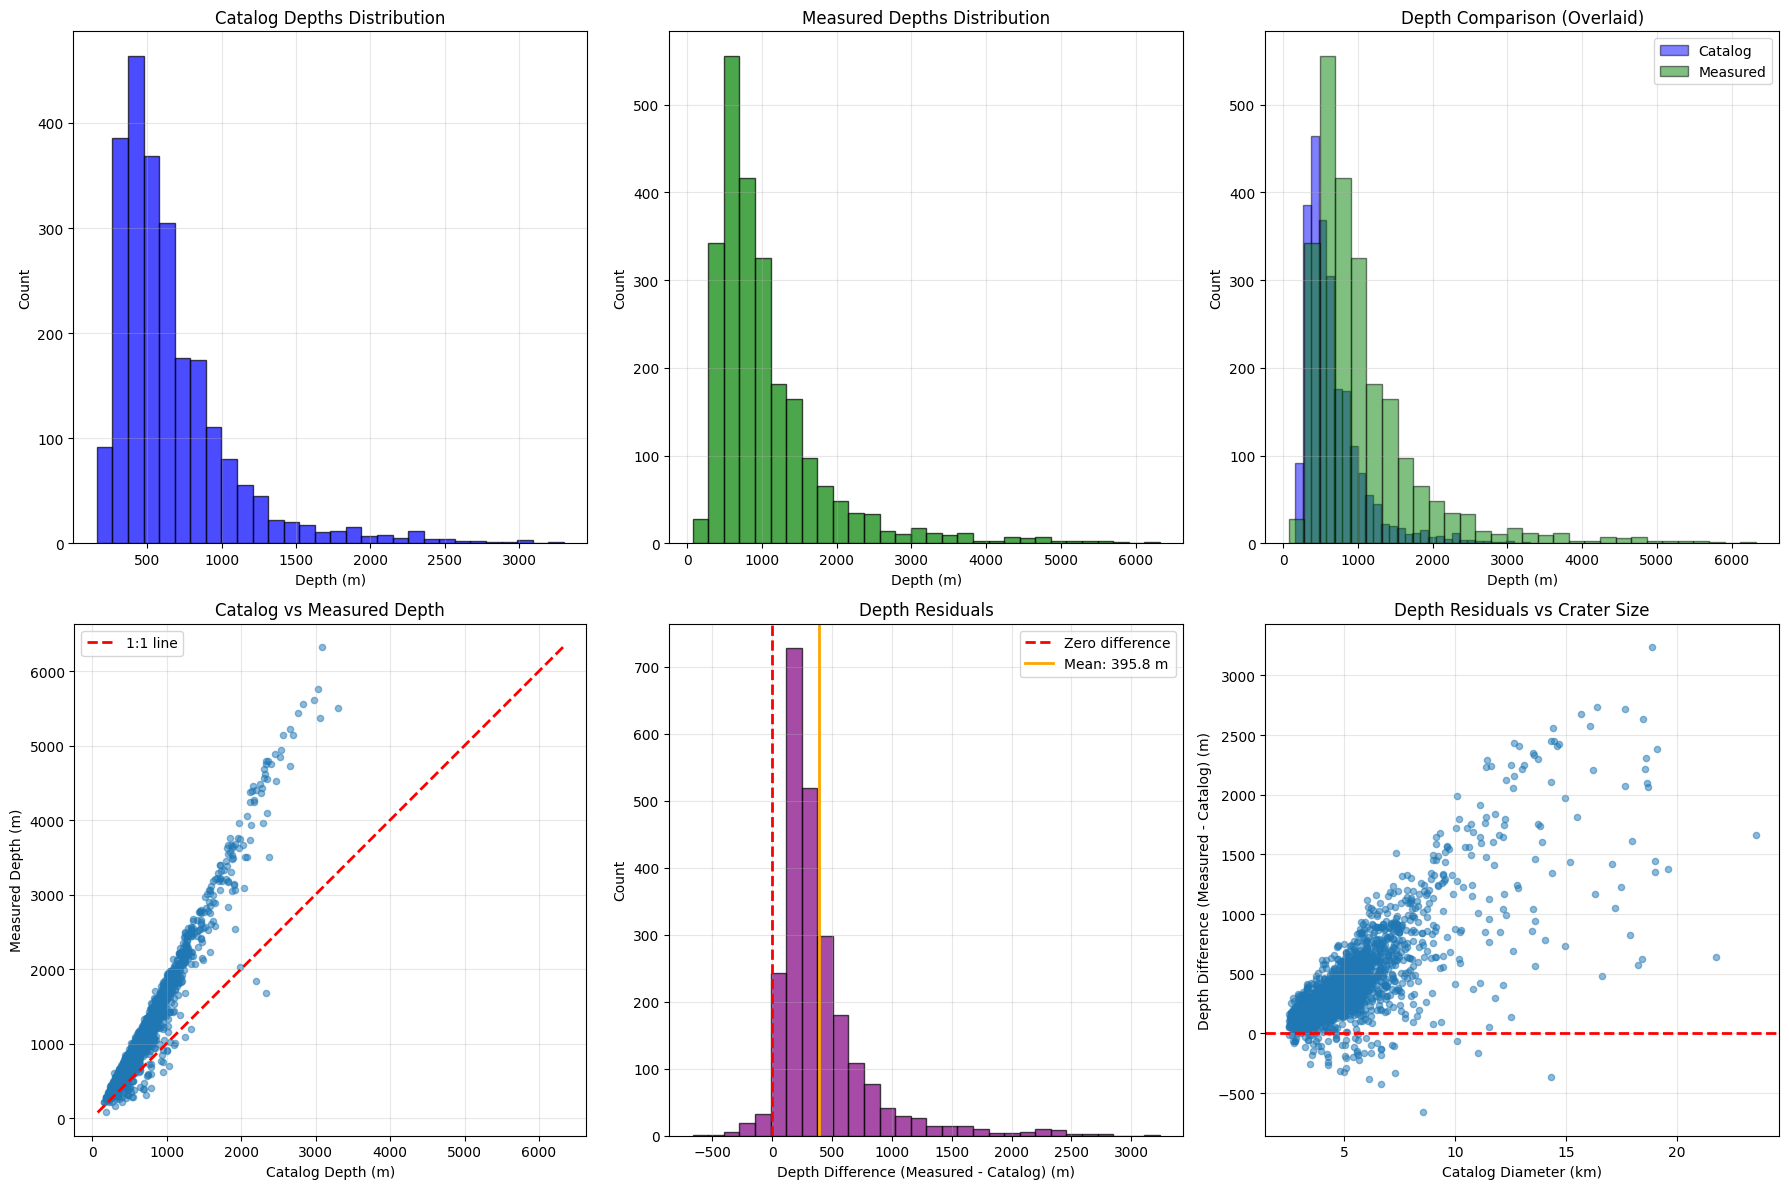


SUMMARY STATISTICS

Catalog Depths:
  Mean: 658.5 m
  Median: 547.7 m
  Std Dev: 402.7 m
  Range: 160.0 - 3301.2 m

Measured Depths:
  Mean: 1054.3 m
  Median: 828.0 m
  Std Dev: 775.2 m
  Range: 74.5 - 6322.2 m

Depth Differences (Measured - Catalog):
  Mean: 395.8 m
  Median: 283.9 m
  Std Dev: 392.8 m
  Range: -662.7 - 3237.5 m

Correlation (Catalog vs Measured): 0.975
Percentage where Measured > Catalog: 97.3%


In [37]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Histogram of catalog depths
axes[0, 0].hist(catalog_depths, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_xlabel('Depth (m)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Catalog Depths Distribution')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram of measured depths
axes[0, 1].hist(measured_depths, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Depth (m)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Measured Depths Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Overlaid histograms for direct comparison
axes[0, 2].hist(catalog_depths, bins=30, alpha=0.5, color='blue', edgecolor='black', label='Catalog')
axes[0, 2].hist(measured_depths, bins=30, alpha=0.5, color='green', edgecolor='black', label='Measured')
axes[0, 2].set_xlabel('Depth (m)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Depth Comparison (Overlaid)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Scatter plot: Catalog vs Measured depths
axes[1, 0].scatter(catalog_depths, measured_depths, alpha=0.5, s=20)
max_depth = max(catalog_depths.max(), measured_depths.max())
min_depth = min(catalog_depths.min(), measured_depths.min())
axes[1, 0].plot([min_depth, max_depth], [min_depth, max_depth], 'r--', linewidth=2, label='1:1 line')
axes[1, 0].set_xlabel('Catalog Depth (m)')
axes[1, 0].set_ylabel('Measured Depth (m)')
axes[1, 0].set_title('Catalog vs Measured Depth')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_aspect('equal', adjustable='box')

# 5. Histogram of depth differences (residuals)
depth_diff = measured_depths - catalog_depths
axes[1, 1].hist(depth_diff, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero difference')
axes[1, 1].axvline(x=np.mean(depth_diff), color='orange', linestyle='-', linewidth=2, 
                   label=f'Mean: {np.mean(depth_diff):.1f} m')
axes[1, 1].set_xlabel('Depth Difference (Measured - Catalog) (m)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Depth Residuals')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Depth difference vs catalog diameter (to check for size-dependent bias)
axes[1, 2].scatter(catalog_diameters, depth_diff, alpha=0.5, s=20)
axes[1, 2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 2].set_xlabel('Catalog Diameter (km)')
axes[1, 2].set_ylabel('Depth Difference (Measured - Catalog) (m)')
axes[1, 2].set_title('Depth Residuals vs Crater Size')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('../figures/depth_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nCatalog Depths:")
print(f"  Mean: {np.mean(catalog_depths):.1f} m")
print(f"  Median: {np.median(catalog_depths):.1f} m")
print(f"  Std Dev: {np.std(catalog_depths):.1f} m")
print(f"  Range: {np.min(catalog_depths):.1f} - {np.max(catalog_depths):.1f} m")

print(f"\nMeasured Depths:")
print(f"  Mean: {np.mean(measured_depths):.1f} m")
print(f"  Median: {np.median(measured_depths):.1f} m")
print(f"  Std Dev: {np.std(measured_depths):.1f} m")
print(f"  Range: {np.min(measured_depths):.1f} - {np.max(measured_depths):.1f} m")

print(f"\nDepth Differences (Measured - Catalog):")
print(f"  Mean: {np.mean(depth_diff):.1f} m")
print(f"  Median: {np.median(depth_diff):.1f} m")
print(f"  Std Dev: {np.std(depth_diff):.1f} m")
print(f"  Range: {np.min(depth_diff):.1f} - {np.max(depth_diff):.1f} m")

# Correlation coefficient
correlation = np.corrcoef(catalog_depths, measured_depths)[0, 1]
print(f"\nCorrelation (Catalog vs Measured): {correlation:.3f}")

# Percentage of craters where measured > catalog
pct_deeper = np.sum(measured_depths > catalog_depths) / len(measured_depths) * 100
print(f"Percentage where Measured > Catalog: {pct_deeper:.1f}%")

In [38]:
# Plot depth/diameter ratio vs latitude - matching reproduce_rubanenko_fig1.ipynb style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === OPTION: Include failed craters in binned averages ===
INCLUDE_FAILED_IN_BINS = True  # Set to False to exclude failed craters from binned averages

# Get latitudes for successfully processed craters
latitudes = np.array([crater_objects[i].global_coords['lat'] for i in results['crater_idx']])

# Calculate depth/diameter ratio (convert diameter from km to m for consistent units)
# depth is in meters, diameter is in km, so multiply diameter by 1000
d_D_ratio_measured = measured_depths / (measured_diameters * 1000)
d_D_ratio_catalog = catalog_depths / (catalog_diameters * 1000)

# Get data for FAILED craters (from catalog only)
failed_indices = [idx for idx, _ in results['error_craters']]
failed_latitudes = np.array([crater_objects[i].global_coords['lat'] for i in failed_indices])
failed_catalog_depths = np.array([crater_objects[i].get_property('depth_m') for i in failed_indices])
failed_catalog_diameters = np.array([crater_objects[i].get_property('diameter_km') for i in failed_indices])
failed_d_D_catalog = failed_catalog_depths / (failed_catalog_diameters * 1000)

# Use absolute latitude for plotting
abs_latitudes = np.abs(latitudes)
abs_failed_latitudes = np.abs(failed_latitudes)

# Create DataFrame for binning
if INCLUDE_FAILED_IN_BINS and len(failed_indices) > 0:
    # Combine successful and failed craters for catalog d/D binning
    all_abs_latitudes = np.concatenate([abs_latitudes, abs_failed_latitudes])
    all_d_D_catalog = np.concatenate([d_D_ratio_catalog, failed_d_D_catalog])
    
    df = pd.DataFrame({
        'lat': abs_latitudes,
        'd_D_measured': d_D_ratio_measured,
        'd_D_catalog': d_D_ratio_catalog
    })
    
    df_all = pd.DataFrame({
        'lat': all_abs_latitudes,
        'd_D_catalog': all_d_D_catalog
    })
    bin_label = f"(including {len(failed_indices)} failed)"
else:
    df = pd.DataFrame({
        'lat': abs_latitudes,
        'd_D_measured': d_D_ratio_measured,
        'd_D_catalog': d_D_ratio_catalog
    })
    df_all = df
    bin_label = "(successful only)"

# Binning parameters
n_bins = 10
lat_bins = np.linspace(df['lat'].min(), df['lat'].max(), n_bins + 1)
bin_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

# Calculate binned statistics for measured data (always successful only)
measured_means = []
measured_sems = []
for i in range(len(lat_bins) - 1):
    mask = (df['lat'] >= lat_bins[i]) & (df['lat'] < lat_bins[i+1])
    bin_data = df[mask]['d_D_measured']
    if len(bin_data) > 0:
        measured_means.append(bin_data.mean())
        measured_sems.append(bin_data.std() / np.sqrt(len(bin_data)))
    else:
        measured_means.append(np.nan)
        measured_sems.append(np.nan)

measured_means = np.array(measured_means)
measured_sems = np.array(measured_sems)

# Calculate binned statistics for catalog data (optionally including failed)
catalog_means = []
catalog_sems = []
for i in range(len(lat_bins) - 1):
    mask = (df_all['lat'] >= lat_bins[i]) & (df_all['lat'] < lat_bins[i+1])
    bin_data = df_all[mask]['d_D_catalog']
    if len(bin_data) > 0:
        catalog_means.append(bin_data.mean())
        catalog_sems.append(bin_data.std() / np.sqrt(len(bin_data)))
    else:
        catalog_means.append(np.nan)
        catalog_sems.append(np.nan)

catalog_means = np.array(catalog_means)
catalog_sems = np.array(catalog_sems)

print(f"Successfully processed: {len(abs_latitudes)} craters")
print(f"Failed to process: {len(abs_failed_latitudes)} craters")
print(f"Include failed in catalog bins: {INCLUDE_FAILED_IN_BINS}")

# Plot 1: Measured d/D vs Latitude (with failed craters shown)
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.scatter(abs_latitudes, d_D_ratio_measured, alpha=0.3, s=10, color='blue', label='Successful craters')
ax1.scatter(abs_failed_latitudes, failed_d_D_catalog, alpha=0.5, s=20, color='red', marker='x', label=f'Failed craters (n={len(failed_indices)})')
ax1.errorbar(bin_centers, measured_means, yerr=measured_sems, 
             color='red', linewidth=2, marker='o', markersize=6,
             capsize=5, label=f'Binned average (n={n_bins})')
ax1.set_xlabel('Latitude (degrees)', fontsize=12)
ax1.set_ylabel('Depth/Diameter Ratio', fontsize=12)
ax1.set_title('Measured d/D vs Latitude (red X = failed craters, catalog d/D shown)')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0.03, 0.2)
plt.tight_layout()
plt.show()

# Plot 2: Catalog d/D vs Latitude (with failed craters shown)
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.scatter(abs_latitudes, d_D_ratio_catalog, alpha=0.3, s=10, color='blue', label='Successful craters')
ax2.scatter(abs_failed_latitudes, failed_d_D_catalog, alpha=0.5, s=20, color='red', marker='x', label=f'Failed craters (n={len(failed_indices)})')
ax2.errorbar(bin_centers, catalog_means, yerr=catalog_sems, 
             color='red', linewidth=2, marker='o', markersize=6,
             capsize=5, label=f'Binned average {bin_label}')
ax2.set_xlabel('Latitude (degrees)', fontsize=12)
ax2.set_ylabel('Depth/Diameter Ratio', fontsize=12)
ax2.set_title(f'Catalog d/D vs Latitude {bin_label}')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(0.03, 0.2)
plt.tight_layout()
plt.show()

# Plot 3: Comparison - Both on same plot
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.scatter(abs_latitudes, d_D_ratio_measured, alpha=0.2, s=10, color='blue', label='_nolegend_')
ax3.scatter(abs_latitudes, d_D_ratio_catalog, alpha=0.2, s=10, color='orange', label='_nolegend_')
ax3.scatter(abs_failed_latitudes, failed_d_D_catalog, alpha=0.5, s=20, color='red', marker='x', label=f'Failed craters (n={len(failed_indices)})')
ax3.errorbar(bin_centers, measured_means, yerr=measured_sems, 
             color='blue', linewidth=2, marker='o', markersize=6,
             capsize=5, label='Measured (binned)')
ax3.errorbar(bin_centers, catalog_means, yerr=catalog_sems, 
             color='red', linewidth=2, marker='s', markersize=6,
             capsize=5, label=f'Catalog (binned) {bin_label}')
ax3.set_xlabel('Latitude (degrees)', fontsize=12)
ax3.set_ylabel('Depth/Diameter Ratio', fontsize=12)
ax3.set_title('d/D vs Latitude - Measured vs Catalog Comparison')
ax3.grid(True, alpha=0.3)
ax3.legend()
ax3.set_ylim(0.03, 0.2)
plt.tight_layout()
plt.show()

# Show distribution of failed craters by latitude
if len(failed_indices) > 0:
    fig4, ax4 = plt.subplots(figsize=(10, 4))
    ax4.hist(abs_failed_latitudes, bins=20, alpha=0.7, color='red', edgecolor='black', label='Failed')
    ax4.hist(abs_latitudes, bins=20, alpha=0.5, color='blue', edgecolor='black', label='Successful')
    ax4.set_xlabel('Latitude (degrees)', fontsize=12)
    ax4.set_ylabel('Count', fontsize=12)
    ax4.set_title('Distribution of Failed vs Successful Craters by Latitude')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

ValueError: All arrays must be of the same length